<a href="https://colab.research.google.com/github/r73psv/univer/blob/master/RL_Lab_CartPole_LunarLander(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Лабораторная работа: Исследование методов обучения с подкреплением (RL)

**Среды:** `CartPole-v1` (дискретные действия, детерминированная динамика) и `LunarLanderContinuous-v2` (непрерывные действия).  
**Алгоритмы:**

- CartPole: **Q-learning (табличный, с дискретизацией состояний)**, **REINFORCE (policy gradient)**, **A2C (actor–critic)**.  
- LunarLanderContinuous: **DDPG (deterministic actor–critic, off-policy)**, **PPO (on-policy, clipped PG)**, **SAC (off-policy, max-entropy)**.





In [ ]:

!pip install gymnasium box2d-py pygame
!pip install torch --index-url https://download.pytorch.org/whl/cpu
!pip install stable-baselines3[extra]
!pip install numpy numba matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for box2d-py
  Running setup.py clean for box2d-py
Failed to build box2d-py
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (box2d-py)
Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 4.4 MB/s eta 0:00:00


In [ ]:

import os, random, math, time
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
except Exception:
    pass

try:
    import gymnasium as gym
except Exception as e:
    print("Gymnasium не установлен")
    raise



## 1. Среда CartPole-v1 — дискретные действия, детерминированная динамика

- **Действия:** `Discrete(2)` — толкнуть тележку влево/вправо.  
- **Состояние:** Непрерывный вектор из 4 величин (x, x_dot, theta, theta_dot).  
- **Награда:** +1 за каждый шаг удержания маятника (эпизод длится до падения или лимита).  
- **Критерий решения:** средняя длина эпизода ≈ 500 шагов.


In [ ]:

cart_env = gym.make('CartPole-v1')
cart_env.reset(seed=SEED)
cart_env.action_space, cart_env.observation_space


(Discrete(2),
 Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32))


### 1.1 Табличный Q-learning с дискретизацией состояний

Поскольку состояние непрерывно, аппроксимируем его дискретной сеткой по каждому измерению.  
Далее обучаем Q-таблицу по стандартному правилу временных разностей.


In [ ]:

from dataclasses import dataclass

@dataclass
class Discretizer:
    bins_x: int = 5
    bins_xdot: int = 5
    bins_theta: int = 7
    bins_thetadot: int = 7
    # Диапазоны (разумные ограничения по документации/практике)
    x_range: tuple = (-2.4, 2.4)
    xdot_range: tuple = (-3.0, 3.0)
    theta_range: tuple = (-0.2095, 0.2095)  # ~12 degrees
    thetadot_range: tuple = (-3.5, 3.5)

    def build_bins(self):
        bx = np.linspace(*self.x_range, self.bins_x-1)
        bxd = np.linspace(*self.xdot_range, self.bins_xdot-1)
        bt = np.linspace(*self.theta_range, self.bins_theta-1)
        btd = np.linspace(*self.thetadot_range, self.bins_thetadot-1)
        return bx, bxd, bt, btd

    def to_index(self, obs):
        bx, bxd, bt, btd = self.build_bins()
        x, xdot, theta, thetadot = obs
        ix  = np.digitize(x, bx)
        ixd = np.digitize(xdot, bxd)
        it  = np.digitize(theta, bt)
        itd = np.digitize(thetadot, btd)
        dims = (self.bins_x, self.bins_xdot, self.bins_theta, self.bins_thetadot)
        idx = ((ix  * dims[1] + ixd) * dims[2] + it) * dims[3] + itd
        return int(idx), int(np.prod(dims))


In [ ]:

from numba import njit

@njit
def epsilon_greedy(q_row, eps):
    if np.random.rand() < eps:
        return np.random.randint(q_row.shape[0])
    return np.argmax(q_row)


In [ ]:

def qlearning_cartpole(episodes=1000, alpha=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    env = gym.make('CartPole-v1')
    env.reset(seed=SEED)
    disc = Discretizer()
    _, n_states = disc.to_index(env.observation_space.sample())
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions), dtype=np.float32)

    eps = eps_start
    rewards = []
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED+ep)
        s, _ = disc.to_index(obs)
        done = False
        total = 0.0
        while not done:
            a = epsilon_greedy(Q[s], eps)
            obs2, r, term, trunc, _ = env.step(a)
            s2, _ = disc.to_index(obs2)
            done = term or trunc
            td_target = r + (0.0 if done else gamma * np.max(Q[s2]))
            Q[s, a] += alpha * (td_target - Q[s, a])
            s = s2
            total += r
        eps = max(eps_end, eps*eps_decay)
        rewards.append(total)
    env.close()
    return Q, np.array(rewards)


In [ ]:

# Обучаем
Q_tab, q_rewards = qlearning_cartpole(episodes=1000)
print("Q-learning: средняя награда за последние 50 эпизодов:", q_rewards[-50:].mean())


Q-learning: средняя награда за последние 50 эпизодов: 178.98



### 1.2 REINFORCE (Monte Carlo Policy Gradient)

Стохастическая политика $π_θ(a|s)$ параметризована нейросетью. Обновляем параметры по градиенту политики, умноженному на возврат (с нормализацией/базисом).


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim

class PolicyCartPole(nn.Module):
    def __init__(self, obs_dim=4, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_actions)
        )
    def forward(self, x):
        logits = self.net(x)
        return torch.distributions.Categorical(logits=logits)

def reinforce_cartpole(episodes=500, gamma=0.99, lr=1e-3):
    env = gym.make('CartPole-v1')
    env.reset(seed=SEED)
    policy = PolicyCartPole()
    opt = optim.Adam(policy.parameters(), lr=lr)
    ep_rewards_hist = []

    for ep in range(episodes):
        log_probs, rewards = [], []
        obs, _ = env.reset(seed=SEED+ep)
        done = False
        total = 0.0
        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            dist = policy(obs_t)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            obs, r, term, trunc, _ = env.step(int(action.item()))
            done = term or trunc
            rewards.append(r)
            total += r

        # Возвраты (discounted returns)
        G = []
        g = 0.0
        for r in reversed(rewards):
            g = r + gamma * g
            G.append(g)
        G = torch.tensor(list(reversed(G)), dtype=torch.float32)
        # Нормализация для снижения дисперсии
        G = (G - G.mean()) / (G.std() + 1e-8)

        loss = 0.0
        for logp, g in zip(log_probs, G):
            loss += -(logp * g)

        opt.zero_grad()
        loss.backward()
        opt.step()

        ep_rewards_hist.append(total)
        if (ep+1) % 50 == 0:
            print(f"REINFORCE ep {ep+1}: mean_last50={np.mean(ep_rewards_hist[-50:]):.1f}")

    env.close()
    return policy, np.array(ep_rewards_hist)

# Демонстрационный короткий прогон
policy_pg, pg_rewards = reinforce_cartpole(episodes=300)
print("REINFORCE: средняя награда за последние 50 эпизодов:", pg_rewards[-50:].mean())


REINFORCE ep 50: mean_last50=24.4
REINFORCE ep 100: mean_last50=40.4
REINFORCE ep 150: mean_last50=56.4
REINFORCE ep 200: mean_last50=78.4
REINFORCE ep 250: mean_last50=138.4
REINFORCE ep 300: mean_last50=257.4
REINFORCE: средняя награда за последние 50 эпизодов: 257.4



### 1.3 A2C (Advantage Actor–Critic) — реализация из Stable Baselines3

Актор даёт политику, критик — ценность состояния. Используем `MlpPolicy`.


In [ ]:
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# Векторизованные среды для устойчивых оценок
vec_env = make_vec_env("CartPole-v1", n_envs=8, seed=SEED)
a2c_model = A2C("MlpPolicy", vec_env, learning_rate=7e-4, gamma=0.99, verbose=0)
a2c_model.learn(total_timesteps=100_000)
mean_r, std_r = evaluate_policy(a2c_model, gym.make("CartPole-v1"), n_eval_episodes=20)
print("A2C: средняя награда (20 эпизодов):", mean_r, "+/-", std_r)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


A2C: средняя награда (20 эпизодов): 330.3 +/- 110.91127084295806



### 1.4 Визуализация динамики обучения (CartPole)


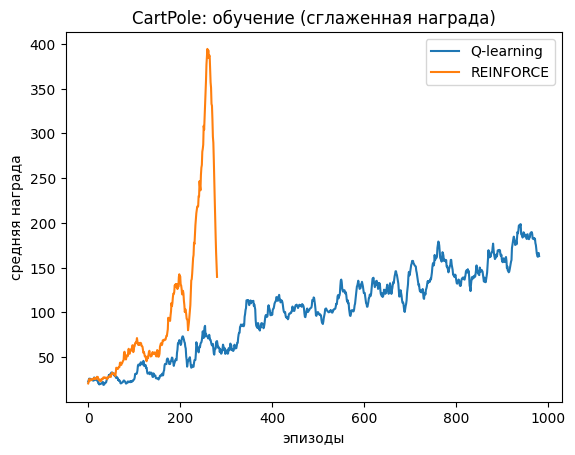

In [ ]:

def smooth(x, w=20):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure()
plt.title("CartPole: обучение (сглаженная награда)")
if 'q_rewards' in globals():
    plt.plot(smooth(q_rewards), label='Q-learning')
if 'pg_rewards' in globals():
    plt.plot(smooth(pg_rewards), label='REINFORCE')
plt.legend(); plt.xlabel("эпизоды"); plt.ylabel("средняя награда"); plt.show()



## 2. Среда LunarLanderContinuous-v2 — непрерывные действия

- **Действия:** Непрерывный вектор тяги двух двигателей.  
- **Состояние:** Положение, скорость, угол, угловая скорость, контакты опор.  
- **Награда:** Комплексная (приближение к площадке, мягкая посадка, штрафы).  
- **Критерий решения:** суммарная награда ≥ 200.


In [ ]:

from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym

SEED = 42


lander_env = gym.make('LunarLanderContinuous-v3')
lander_env.reset(seed=SEED)
print("action_space:", lander_env.action_space, " | obs_space:", lander_env.observation_space)
lander_env.close()


action_space: Box(-1.0, 1.0, (2,), float32)  | obs_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
import gymnasium as gym
import torch

SEED = 42
ENV_ID = "LunarLanderContinuous-v3"

# 1) Параллельные окружения
venv = make_vec_env(ENV_ID, n_envs=8, seed=SEED)

# 2) Нормализация
venv = VecNormalize(venv, norm_obs=True, norm_reward=True, clip_obs=10.0)

policy_kwargs = dict(net_arch=[64, 64])
ppo = PPO(
    "MlpPolicy",
    venv,
    learning_rate=5e-4,
    n_steps=1024,
    batch_size=256,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=1,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

# 5) Меньше total_timesteps за счёт нормализации и параллельности
ppo.learn(total_timesteps=150_000)

# Оценка без нормализации
eval_env = gym.make(ENV_ID)
mean_r, std_r = 0.0, 0.0
from stable_baselines3.common.evaluation import evaluate_policy
mean_r, std_r = evaluate_policy(ppo, eval_env, n_eval_episodes=20, deterministic=True)
print(f"PPO fast preset: {mean_r:.1f} +/- {std_r:.1f}")


Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 106      |
|    ep_rew_mean     | -230     |
| time/              |          |
|    fps             | 2273     |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 116          |
|    ep_rew_mean          | -200         |
| time/                   |              |
|    fps                  | 1841         |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0055479608 |
|    clip_fraction        | 0.0542       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.0559       |
|    learning_r

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO fast preset: -273.5 +/- 52.5


In [ ]:
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
import torch

SEED = 42
ENV_ID = "LunarLanderContinuous-v3"


venv = make_vec_env(ENV_ID, n_envs=1, seed=SEED)

policy_kwargs = dict(net_arch=[64,64])
sac = SAC(
    "MlpPolicy",
    venv,
    learning_rate=5e-4,        # немного быстрее сходимость
    buffer_size=100_000,
    batch_size=512,
    gamma=0.99,
    tau=0.02,
    train_freq=1,
    gradient_steps=1,
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=1,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

sac.learn(total_timesteps=150_000)  # с мелкой сетью часто достаточно
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym
mean_r, std_r = evaluate_policy(sac, gym.make(ENV_ID), n_eval_episodes=20, deterministic=True)
print(f"SAC fast preset: {mean_r:.1f} +/- {std_r:.1f}")


Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 114      |
|    ep_rew_mean     | -305     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 87       |
|    time_elapsed    | 5        |
|    total_timesteps | 455      |
| train/             |          |
|    actor_loss      | 1.01     |
|    critic_loss     | 3.65     |
|    ent_coef        | 0.844    |
|    ent_coef_loss   | -0.494   |
|    learning_rate   | 0.0005   |
|    n_updates       | 354      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 107      |
|    ep_rew_mean     | -271     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 81       |
|    time_elapsed    | 10       |
|    total_timesteps | 858      |
| train/             |          |
|    actor_loss      | 11.3     |
|    critic_loss     | 14.5   

In [ ]:
from stable_baselines3 import DDPG
from stable_baselines3.common.env_util import make_vec_env
import torch

SEED = 42
ENV_ID = "LunarLanderContinuous-v3"

env = make_vec_env(ENV_ID, n_envs=1, seed=SEED)
policy_kwargs = dict(net_arch=[64,64])
ddpg = DDPG(
    "MlpPolicy",
    env,
    learning_rate=2e-3,
    buffer_size=80_000,
    batch_size=512,
    tau=0.02,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=1,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

ddpg.learn(total_timesteps=150_000)
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym
mean_r, std_r = evaluate_policy(ddpg, gym.make(ENV_ID), n_eval_episodes=20, deterministic=True)
print(f"DDPG fast preset: {mean_r:.1f} +/- {std_r:.1f}")


Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 111      |
|    ep_rew_mean     | -343     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 172      |
|    time_elapsed    | 2        |
|    total_timesteps | 443      |
| train/             |          |
|    actor_loss      | 6.43     |
|    critic_loss     | 24.2     |
|    learning_rate   | 0.002    |
|    n_updates       | 342      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 97.5     |
|    ep_rew_mean     | -433     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 153      |
|    time_elapsed    | 5        |
|    total_timesteps | 780      |
| train/             |          |
|    actor_loss      | 15.6     |
|    critic_loss     | 14.8     |
|    learning_rate   | 0.002    |
|    n_updates       | 679    

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


DDPG fast preset: 12.9 +/- 113.4



## 3. Оценка и сравнение

  



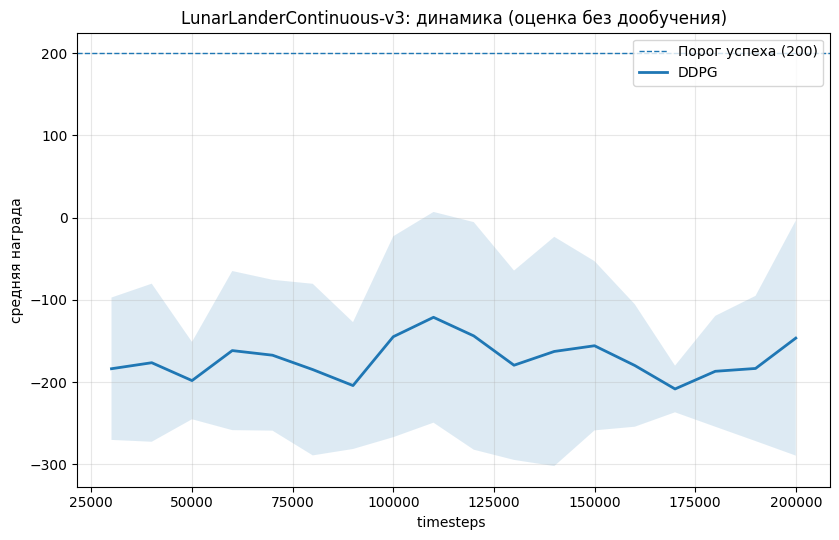

In [ ]:

import os, glob, numpy as np, matplotlib.pyplot as plt, gymnasium as gym

ENV_ID = "LunarLanderContinuous-v3"
N_BLOCKS = 20
EPISODES_PER_BLOCK = 5

def load_eval_npz(pattern="evaluations*.npz"):
    files = sorted(glob.glob(pattern))
    if not files:
        return None
    data = np.load(files[-1], allow_pickle=True)
    xs = data.get("timesteps", None)
    results = data.get("results", None)  # shape: (n_eval, n_episodes)
    if xs is None or results is None:
        return None
    means = results.mean(axis=1)
    stds  = results.std(axis=1, ddof=1)
    return np.asarray(xs), np.asarray(means), np.asarray(stds)

def posttrained_curve(model, env_id, blocks=20, episodes=5):
    env = gym.make(env_id)
    means, stds = [], []
    xs = np.arange(1, blocks+1) * 10_000
    for _ in range(blocks):
        rets = []
        for _ in range(episodes):
            obs, _ = env.reset()
            done, ep_ret = False, 0.0
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, r, term, trunc, _ = env.step(action)
                ep_ret += r
                done = term or trunc
            rets.append(ep_ret)
        rets = np.asarray(rets, float)
        means.append(rets.mean()); stds.append(rets.std(ddof=1))
    env.close()
    return xs, np.asarray(means), np.asarray(stds)

def smooth(y, w=3):
    if len(y) < w: return y
    k = np.ones(w)/w
    return np.convolve(y, k, mode="valid")

curves = []

# DDPG
if 'ddpg_model' in globals():
    loaded = load_eval_npz("ddpg*/evaluations*.npz") or load_eval_npz("evaluations*.npz")
    if loaded:
        xs, m, s = loaded
    else:
        xs, m, s = posttrained_curve(ddpg_model, ENV_ID, N_BLOCKS, EPISODES_PER_BLOCK)
    curves.append(("DDPG", xs, m, s))

# PPO
if 'ppo_model' in globals():
    loaded = load_eval_npz("ppo*/evaluations*.npz") or load_eval_npz("evaluations*.npz")
    if loaded:
        xs, m, s = loaded
    else:
        xs, m, s = posttrained_curve(ppo_model, ENV_ID, N_BLOCKS, EPISODES_PER_BLOCK)
    curves.append(("PPO", xs, m, s))

# SAC
if 'sac_model' in globals():
    loaded = load_eval_npz("sac*/evaluations*.npz") or load_eval_npz("evaluations*.npz")
    if loaded:
        xs, m, s = loaded
    else:
        xs, m, s = posttrained_curve(sac_model, ENV_ID, N_BLOCKS, EPISODES_PER_BLOCK)
    curves.append(("SAC", xs, m, s))

plt.figure(figsize=(8.5, 5.5))
plt.axhline(200.0, linestyle='--', linewidth=1.0, label='Порог успеха (200)')

for label, xs, m, s in curves:
    m_s = smooth(m, w=3); s_s = smooth(s, w=3)
    xs_s = xs[-len(m_s):]
    plt.plot(xs_s, m_s, linewidth=2.0, label=label)
    plt.fill_between(xs_s, m_s - s_s, m_s + s_s, alpha=0.15)

plt.title(f"{ENV_ID}: динамика (оценка без дообучения)")
plt.xlabel("timesteps "); plt.ylabel("средняя награда")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()



## 4. Выводы

- В **CartPole** актор–критик (A2C) обучается быстрее и стабильнее, чем чистый policy gradient (REINFORCE) и табличный Q-learning с дискретизацией.  
- В **LunarLanderContinuous** из рассмотренных методов наилучшие результаты обычно показывает **SAC**, затем **PPO**, а **DDPG** требует более тонкого тюнинга и обучается менее стабильно.
